In [ ]:
from matplotlib import pyplot as plt
from tqdm import tqdm
import itertools
import os
import numpy as np
import scipy.sparse
import pandas as pd
import re
import importlib.util
import sys
import scanpy as sc
import seaborn as sns

In [ ]:
import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

In [ ]:
sc.set_figure_params(dpi=80)
plt.rcParams['axes.grid'] = False


General functions

In [ ]:
def get_quantile(v, q):
    return(np.min(np.where(np.cumsum(v) >= q)))
def get_mean(v1, v2):
    return(np.sum(v1*v2))

### Import dataset

In [ ]:
adata_all = sc.read_h5ad("../data/Reyes_Xenium_TIER_all_SUBSET_all__annotated.h5ad")

### Plot conditional density maps

In [ ]:
def plot_conditional_distribution(xval, yval, bins, log = False, cmap = 'viridis', vmin = 0, vmax = 0.1):
    if log:
        xval[xval == 0] = np.min(xval[xval > 0])
        yval[yval == 0] = np.min(yval[yval > 0])
        xval = np.log(xval)/np.log(10)
        yval = np.log(yval)/np.log(10)
    h = np.histogram2d(xval, yval, bins = bins)
    xcounts = h[0].sum(axis=0)
    ycounts = h[0].sum(axis=1)    
    conditional_distribution = (h[0].T / h[0].sum(axis=1)).T
    f = plt.figure()
    plt.imshow(conditional_distribution.T, origin = 'lower', cmap = cmap, vmin = vmin, vmax = vmax)
    return conditional_distribution, [h[1], h[2]]

In [ ]:
selected_cells = adata_all.obs['condition'].to_numpy() == 'K3_shp53'

min_cells_x = 5
denominator_columns_x = ['count_OBS_cell_type_0_CAT_Epithelial']
numerator_columns_x = ['count_OBS_cell_type_1_CAT_progenitor1', 'count_OBS_cell_type_1_CAT_progenitor2']

min_cells_y = 5
denominator_columns_y = ['count_OBS_cell_type_0_CAT_Immune_Myeloid']
numerator_columns_y = ['count_OBS_cell_type_1_CAT_TAM_Cd274']

ylabel = "Itgax+/Cd274high\n(log fraction of myeloid)"
xlabel = "progenitor\n(log fraction of epithelial)"


### Plot conditional density maps

In [ ]:
selected_radius = 200

df = pd.read_csv(os.path.join("../cell_type_counts", "celltype_counts_RADIUS_" + str(selected_radius) + ".csv.gz"))
df = df.loc[selected_cells,:].copy()


/data/lowe/reyesj3/repositories/temp/ipykernel_95687/2457304994.py:9: RuntimeWarning: invalid value encountered in divide
  xval = count_x_subtype / count_x_type
/data/lowe/reyesj3/repositories/temp/ipykernel_95687/2457304994.py:10: RuntimeWarning: invalid value encountered in divide
  yval = count_y_subtype / count_y_type


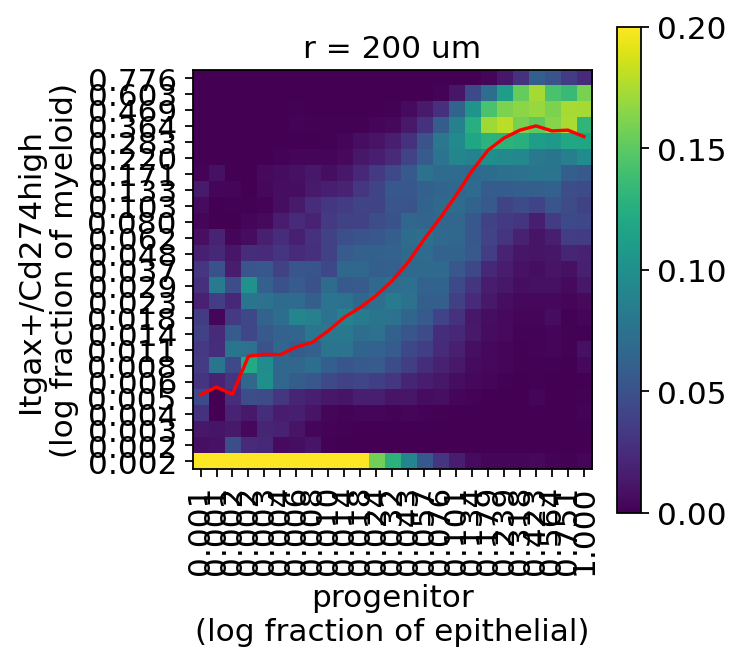

In [ ]:
count_x_type = df.loc[:,denominator_columns_x].sum(axis=1).to_numpy()
count_x_subtype = df.loc[:,numerator_columns_x].sum(axis=1).to_numpy()
valid_niche_x = count_x_type >= min_cells_x

count_y_type = df.loc[:,denominator_columns_y].sum(axis=1).to_numpy()
count_y_subtype = df.loc[:,numerator_columns_y].sum(axis=1).to_numpy()
valid_niche_y = count_y_type >= min_cells_y

xval = count_x_subtype / count_x_type
yval = count_y_subtype / count_y_type

valid_niche_joint = np.logical_and(valid_niche_y, valid_niche_x)

log_values = True
h, bins = plot_conditional_distribution(
    xval[valid_niche_joint], yval[valid_niche_joint], [25,25], log = log_values, vmax = 0.2, cmap = 'viridis')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title("r = " + str(selected_radius) + " um")

yval = bins[0] + np.diff(bins[0])[0]
yval2 = np.array(list(range(len(yval))))
xval = bins[1] + np.diff(bins[1])[0]
means1 = [get_mean(h[i,:], yval2[1:]) for i in range(h.shape[0])]
plt.plot(range(len(xval[:-1])), means1, color='r')
if log_values:
    plt.xticks(range(len(yval)-1), [f"{x:.3f}" for x in np.power(10, yval[:-1])], rotation = 90)
    plt.yticks(range(len(xval)-1), [f"{x:.3f}" for x in np.power(10, xval[:-1])])
else:
    plt.xticks(range(len(yval)-1), [f"{x:.2f}" for x in yval[:-1]], rotation = 90)
    plt.yticks(range(len(xval)-1), [f"{x:.2f}" for x in xval[:-1]])

plt.colorbar()
